# Congressional voting records dataset

[UCI webpage](https://archive.ics.uci.edu/dataset/105/congressional+voting+records)

First, we import the libraries that we will need to load, process and visualize the data.

Details about the different libraries and provided functions can be found in their respective documentation:
- `numpy` for numerical calculations https://numpy.org/doc/stable/
- `pandas` for data manipulation and analysis https://pandas.pydata.org/docs/
- `pyplot` from `matplotlib` for basic plotting functionalities https://matplotlib.org/stable/
- `seaborn` for data visualization https://seaborn.pydata.org/

The first line below is a Python 'magic command' to display the plots in the notebook.
The last line is to somewhat increase the default figure width.

In [1]:
%matplotlib inline
import numpy
import pandas
import matplotlib.pyplot as plt
import seaborn

plt.rcParams["figure.figsize"] = (10, 5)

Quoting the dataset information from the [UCI webpage](https://archive.ics.uci.edu/dataset/105/congressional+voting+records)

> This data set includes votes for each of the U.S. House of Representatives Congressmen on the 16 key votes identified by the CQA.
> The CQA lists nine different types of votes: voted for, paired for, and announced for (these three simplified to yea), voted against, paired against, and announced against (these three simplified to nay), voted present, voted present to avoid conflict of interest, and did not vote or otherwise make a position known (these three simplified to an unknown disposition).

The [Congressional Quarterly Almanac (CQA)](https://library.cqpress.com/cqalmanac/) is a reference source about the activities of each annual session of the United States Congress from 1945 to 2020.

## Loading the data

We load the data from the `house-votes-84.data` file. This file does not contain names for the columns, they can be found in the `house-votes-84.names` file.

We write the list of (shortened) column names and provide it as the `names` input parameter to the `read_csv` function.

In [2]:
# cnames = ["party", "handicapped-infants", "water-project-cost-sharing", "adoption-of-the-budget-resolution",
#          "physician-fee-freeze", "el-salvador-aid", "religious-groups-in-schools", "anti-satellite-test-ban",
#          "aid-to-nicaraguan-contras", "mx-missile", "immigration", "synfuels-corporation-cutback",
#          "education-spending", "superfund-right-to-sue", "crime", "duty-free-exports",
#          "export-administration-act-south-africa"]
cnames = ["party", "infants", "water", "budget", "physician", "el-salvador", "religious", "satellite",
          "nicaragua", "missile", "immigration", "synfuels",
          "education", "superfund", "crime", "exports", "south-africa"]
congress_path = "./congressional+voting+records/house-votes-84.data"
congress_dtf = pandas.read_csv(congress_path, sep=",", names=cnames)

We show an outline of the loaded dataset...

In [3]:
congress_dtf

,party,infants,water,budget,physician,el-salvador,religious,satellite,nicaragua,missile,immigration,synfuels,education,superfund,crime,exports,south-africa
0,republican,n,y,n,y,y,y,n,n,n,y,?,y,y,y,n,y
1,republican,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,?
2,democrat,?,y,y,?,y,y,n,n,n,n,y,n,y,y,n,n
3,democrat,n,y,y,n,?,y,n,n,n,n,y,n,y,n,n,y
4,democrat,y,y,y,n,y,y,n,n,n,n,y,?,y,y,y,y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,republican,n,n,y,y,y,y,n,n,y,y,n,y,y,y,n,y
431,democrat,n,n,y,n,n,n,y,y,y,y,n,n,n,n,n,y
432,republican,n,?,n,y,y,y,n,n,n,n,y,y,y,y,n,y
433,republican,n,n,n,y,y,y,?,?,?,?,n,y,y,y,n,y


...and some descriptive statistics.

Since all columns are categorical, the statistics include for each column
- `count` the total number of values, i.e. the number of rows minus the number of missing values,
- `unique` the number of distinct values,
- `top` the most frequent value, and
- `freq` the occurrence count of the most frequent value.

In [4]:
congress_dtf.describe()

,party,infants,water,budget,physician,el-salvador,religious,satellite,nicaragua,missile,immigration,synfuels,education,superfund,crime,exports,south-africa
count,435,435,435,435,435,435,435,435,435,435,435,435,435,435,435,435,435
unique,2,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
top,democrat,n,y,y,n,y,y,y,y,y,y,n,n,y,y,n,y
freq,267,236,195,253,247,212,272,239,242,207,216,264,233,209,248,233,269


Each of the 435 rows in the dataset represents an elected member of the United States House of Representatives.

The first column indicates the party affiliation of the corresponding representative, as either democrat or republican.
Each of the remaining sixteen columns corresponds to a key vote taken during the second session of the 98th United States Congress, i.e. between January 23 and October 12, 1984.

In this dataset, the vote types are simplified to three outcomes
- **y**, for *Yea*, i.e. vote in favor,
- **n**, for *Nay*, i.e. vote against,
- **?**, no vote, in particular abstention.

Here, we will refer the sixteen votes as *roll calls* and identify each one using the associated short column name.
We will refer to a vote cast either in favor or against as an *expressed vote* and to the third outcome as *abstention*.

In [5]:
parties = sorted(congress_dtf["party"].unique())
print("The dataset contains the votes of " +
      " and ".join(["%s %ss" % (c, p) for (p, c) in congress_dtf["party"].value_counts().items()])+".")

The dataset contains the votes of 267 democrats and 168 republicans.


## Visualizing votes per party

Throughout, we will use colors to represent the different combinations of party and vote type.

Following common conventions, we will use shades of blue for the Democratic Party and shades of red for the Republican Party.
We will use different shades of blue and red to represent the different vote types.
To do this, we will use the 'coolwarm' color map, which varies from bright blue to bright red, through grayish shades.

We map combinations of party and vote type to values in the unit range, so that pairs involving the Democratic Party map to values in the first half while pairs involving the Republican Party map to the second half, and so that values assigned to the same vote type for the two parties are symmetric around the middle of the interval.

In [6]:
codes_votes = [(("democrat", "y"), 0.01), (("democrat", "n"), 0.2), (("democrat", "?"), 0.4), (("democrat", "-"), 0.49), # democrat
             (("republican", "-"), 0.51), (("republican", "?"), 0.6), (("republican", "n"), 0.8), (("republican", "y"), 0.99)]  # republican
map_votes = dict(codes_votes)

We write a function to get a contrasting shade for a given color. That is, for a given value in the unit interval, function `get_contrasting_color` returns the color from the palette that corresponds to a value at the opposite end of the same half, so that the corresponding colors are contrasting shades of the hue.

In [7]:
def get_contrasting_color(vfrac, palette):
    if vfrac < 0.15:
        return palette(0.55)
    elif vfrac < 0.45:
        return palette(0.99)
    elif vfrac < 0.55:
        # in the mid-range, return black
        return (0.,0.,0.,1.)
    elif vfrac < 0.85:
        return palette(0.01)
    else:
        return palette(0.45)

We write a function for plotting the counts of vote types as a stacked horizontal histogram bar.
For readability, we assign somewhat longer labels to the three vote types (see `vote_lbls`).

In [8]:
def make_bar_stack(ax, series, codes_votes, plot_parameters={}, bottom=0, height=1, yoffset_party_lbls=0.1, set_lims=False):
    """Make a stacked horizontal histogram bar for the votes in the series, mapped the provided numerical codes.

        Parameters
        ----------
        ax: pyplot.Axes
            The axes in which to plot the data
        series: pandas.Series
            The series containing the values to plot
        codes_votes: list of tuples
            The sorted list of (party, vote type) pairs with their associated numerical value, as used to obtain the series
        plot_parameters: dict
            Parameters for plotting, such as
            "party_lbls" and "vote_lbls", labels for the parties and vote types, respectively
            "fontsize", "alpha"
        bottom: float
            The y-coordinate of the bottom of the bar
        height: float
            The height of the bar
        yoffset_party_lbls: float
            Offset along the y-coordinate between the bar and the party labels, if None no party label is generated
        set_lims: bool
            Whether to reset the axes limits to wrap around the bar and to turn off the axes
    """

    party_lbls = plot_parameters.get("party_lbls", {"democrat": "Democrats", "republican": "Republicans"})
    vote_lbls = plot_parameters.get("vote_lbls", {"y": "Yea", "n": "Nay", "?": "Abs", "-": ""})
    palette = plot_parameters.get("palette", seaborn.color_palette("coolwarm", as_cmap=True))

    vc = dict(series.value_counts().items())
    sorted_ks, sorted_vs = zip(*codes_votes)
    sorted_colors = [palette(v) for v in sorted_vs]
    sorted_tcolors = [get_contrasting_color(1-v, palette) for v in sorted_vs]
    sorted_counts = [vc.get(v, 0) for v in sorted_vs]
    sorted_cumsum = numpy.cumsum([0]+sorted_counts)

    ax.bar(x=sorted_cumsum[:-1], width=sorted_counts, bottom=bottom, height=height, align="edge", color=sorted_colors)
    for j in range(3):
        for i in [j, len(sorted_ks)-j-1]:
            ax.annotate(text="%s:%d" % (vote_lbls[sorted_ks[i][1]], sorted_counts[i]),
                    xy=((sorted_cumsum[i]+sorted_cumsum[i+1])/2, bottom+0.1+((i-2*(i!=j))%3)*0.3*height),
                    ha="center", fontsize=plot_parameters.get("fontsize", "small"), color=sorted_tcolors[i],
                    bbox=dict(boxstyle="round", pad=.1, lw=0, fc=sorted_colors[i], alpha=plot_parameters.get("alpha", 0.8)))

    if yoffset_party_lbls is not None:
        for (end_id, from_id, to_id) in [(0, 0, 3), (-1, -4, -1)]:
            ax.plot([sorted_cumsum[from_id]+.8, sorted_cumsum[to_id]-.8],
                    [bottom+height+yoffset_party_lbls/2, bottom+height+yoffset_party_lbls/2],
                    color=sorted_colors[end_id], linewidth=1)
            ax.annotate(text=party_lbls[sorted_ks[end_id][0]],
                    xy=((sorted_cumsum[from_id]+sorted_cumsum[to_id])/2, bottom+height+yoffset_party_lbls),
                    ha="center", fontsize=plot_parameters.get("fontsize", "small"), color=sorted_colors[end_id])

    if set_lims:
        ax.set_xlim([0, sorted_cumsum[-1]])
        ax.set_ylim([bottom, bottom+height+3*yoffset_party_lbls])
        ax.axis("off");

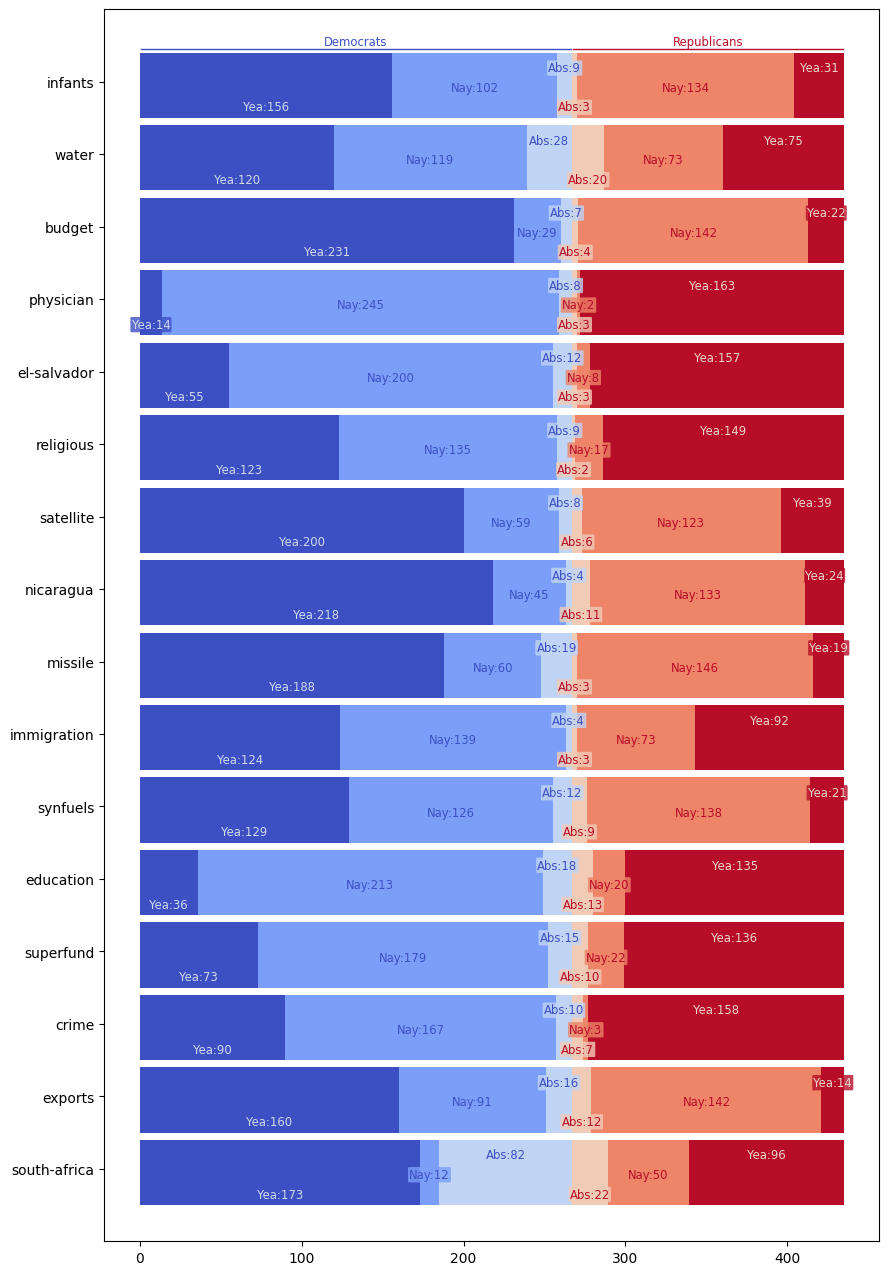

In [9]:
plot_parameters = {"fontsize": "small"}

fig = plt.figure(figsize=(10, 16))
ax = fig.add_subplot()

for i, rc in enumerate(cnames[1:]):
    series = pandas.Series([map_votes.get(tuple(v)) for v in congress_dtf[["party", rc]].values])

    make_bar_stack(ax, series, codes_votes, plot_parameters, bottom=-i, height=0.9,
                                     yoffset_party_lbls=0.1 if i == 0 else None)

ax.set_yticks(*zip(*[(-i+.5, rc) for i, rc in enumerate(cnames[1:])]));
ax.set_ylim([-len(cnames[1:])+.5, 1.5]);

Obviously, in this dataset the number of representatives affiliated with either party is the same for all roll calls, but we can see significant variations in the distribution of votes.

Some votes seem fairly consensual within a party, with all but five republican representatives voting 'Yea' on 'physician', for example. The votes are much more split on some roll calls for both parties, like 'immigration' and even more so 'water'.

The *UCI* dataset provides only very limited information about what the roll calls are about, with mere keywords used as column headers.
The dataset only records the party affiliation of each representative, but no information about their personal identity or even the corresponding congressional district.

In order to better understand the data and be able to analyze it more deeply, we will try to match the records to another source that keeps track of votes taken at the United States Congress and provides more detailed information.

## Data from *Voteview*

We use the [Voteview website](https://voteview.com/) to enrich our dataset.

Specifically, from https://voteview.com/data we download the following three datasets for the 98th session (1983&ndash;1985) of the House of Representatives:
- ***rollcalls*** ([*Congressional Votes*](https://voteview.com/articles/data_help_rollcalls), file [`H098_rollcalls.csv`](https://voteview.com/static/data/out/rollcalls/HS098_rollcalls.csv)), contains details about each roll call, such as the roll call number, bill number, date and description.
- ***members*** ([*Member Ideology*](https://voteview.com/articles/data_help_members), file [`H098_members.csv`](https://voteview.com/static/data/out/members/HS098_members.csv)), contains information about the individual representatives, including their name, party affiliation, state and congressional district.
- ***votes*** ([*Members' Votes*](https://voteview.com/articles/data_help_votes), file [`H098_votes.csv`](https://voteview.com/static/data/out/votes/HS098_votes.csv)), records how each representative voted in each roll call.

We load these three datasets each into a data frame.

In [10]:
H098_path_patt = "./voteview/H098_%s.csv"
H098_dtfs = {}
for (fname, index_col) in [("rollcalls", "rollnumber"), ("members", "icpsr"), ("votes", None)]:
    H098_dtfs[fname] = pandas.read_csv(H098_path_patt % fname, sep=",", index_col=index_col)

We define some useful variables for handling this data.

We list the columns in the *members* dataset that contain biographic information we are interested to retrieve.

In [11]:
biofields = ["state_icpsr", "district_code", "state_abbrev", "party_code", "occupancy", "last_means", "bioname", "born", "died"]

In the *votes* dataset, ten different numerical `cast_codes`, from 0 to 9, are used to represent the different types of votes that can be cast.

In [12]:
H098_dtfs["votes"]["cast_code"].value_counts().sort_index()

cast_code
1    238201
2       840
3       397
4       197
5       816
6    121505
8       449
9     30603
Name: count, dtype: int64

We obtained the clarifications for the cast codes from the data help files, and define the corresponding mapping to the three simplified vote types. We note that the value 0, indicating that the representative in question was not a member of the chamber when the vote was taken, is not used in the *votes* dataset.

In [13]:
cast_codes = ["Not a member of the chamber when this vote was taken", # 0
    "Yea", # 1
    "Paired Yea", # 2
    "Announced Yea", # 3
    "Announced Nay", # 4
    "Paired Nay", # 5
    "Nay", # 6
    "Present (some Congresses)", # 7
    "Present (some Congresses)", # 8
    "Not Voting (Abstention)", # 9
 ]
map_cast_codes_three = dict([(i, "y" if "Yea" in v
                               else "n" if "Nay" in v
                               else "?") for (i, v) in enumerate(cast_codes)])

In the *Voteview* data, the Democratic Party is represented by the value 100 whereas the Republican Party is represented by the value 200.

In [14]:
party_codes = {100: "democrat", 200: "republican"}

We redefine the mapping of combinations of party and vote type to numerical values in the unit interval using these new codes.

In [15]:
rev_party_codes = dict([(v,k) for (k,v) in party_codes.items()])
map_votes_vv = dict([((rev_party_codes[p],v),c) for ((p,v),c) in codes_votes])

Each row in the *votes* dataset records the type of the vote (indicated by a `cast_code`) cast by a representative (identified by their `icpsr` code) in a given roll call (identified by its `rollnumber`).

We use the pivot operation to turn this into a table where each row corresponds to a representative and each column corresponds to a roll call.

In [16]:
H098codes_dtf = H098_dtfs["votes"].pivot(index=["icpsr"], columns="rollnumber", values=["cast_code"]).droplevel(0, axis=1)

Note that the *members* dataset contains one representative for whom there is not any record in the *votes* dataset.

In [17]:
H098_dtfs["members"].loc[~H098_dtfs["members"].index.isin(H098codes_dtf.index), biofields]

,state_icpsr,district_code,state_abbrev,party_code,occupancy,last_means,bioname,born,died
icpsr,,,,,,,,,
15067,62,6,CO,200,5,1,"SWIGERT, John Leonard, Jr. (Jack)",NaN,NaN


Indeed, [Jack Swigert](https://en.wikipedia.org/wiki/Jack_Swigert), a former NASA astronaut on the Apollo 13 mission, was elected to the House of Representatives in 1982 but died later that year before he was sworn in.

We select the roll calls that took place during the second session of the 98th congress, i.e. in the year 1984.

In [18]:
rollnumbers_84 = H098_dtfs["rollcalls"][H098_dtfs["rollcalls"]["date"].str.startswith("1984-")].index

We find representatives who did not take part in any vote during that session, i.e. for whom the *votes* dataset contains no record dated in 1984.

In [19]:
members_allna_84 = H098codes_dtf.loc[H098codes_dtf.loc[:,rollnumbers_84].isna().all(axis=1)].index.to_list()
H098_dtfs["members"].loc[members_allna_84, biofields]

,state_icpsr,district_code,state_abbrev,party_code,occupancy,last_means,bioname,born,died
icpsr,,,,,,,,,
10463,25,4,WI,100,0,1,"ZABLOCKI, Clement John",1912.0,1983.0
10577,71,5,CA,100,1,1,"BURTON, Phillip",1926.0,1983.0
14252,44,7,GA,100,0,1,"McDONALD, Lawrence Patton",1935.0,1983.0
14866,21,1,IL,100,0,1,"WASHINGTON, Harold",1922.0,1987.0


Among them are three representatives who died in 1983, and Harold Washington, who [resigned his congressional seat in April 1983 to become mayor of Chicago](https://en.wikipedia.org/wiki/Harold_Washington#1983_Chicago_mayoral_election).

In the *members* dataset, the representative whose state is recorded as 'USA' is in fact the president of the United States of America, not an actual elected member of the House of Representatives.

In [20]:
president = H098_dtfs["members"].loc[H098_dtfs["members"]["state_abbrev"]=="USA"].index.to_list()
H098_dtfs["members"].loc[president, biofields]

,state_icpsr,district_code,state_abbrev,party_code,occupancy,last_means,bioname,born,died
icpsr,,,,,,,,,
99907,99,0,USA,200,0,0,"REAGAN, Ronald Wilson",1911.0,2004.0


We drop the five corresponding rows, fill any remaining missing vote with value 0, and combine the vote data with the biographic information.

In [21]:
H84codes_dtf = H098codes_dtf.drop(members_allna_84+president, axis=0)[rollnumbers_84].fillna(0)
H84mv_dtf = H098_dtfs["members"][biofields].join(H84codes_dtf, how="inner")
H84mv_dtf

,state_icpsr,district_code,state_abbrev,party_code,occupancy,last_means,bioname,born,died,499,...,897,898,899,900,901,902,903,904,905,906
icpsr,,,,,,,,,,,,,,,,,,,,,
10717,41,2,AL,200,0,1,"DICKINSON, William Louis",1925.0,2008.0,6.0,...,9.0,9.0,9.0,6.0,1.0,6.0,9.0,9.0,9.0,9.0
10721,41,1,AL,200,0,1,"EDWARDS, William Jackson (Jack)",1928.0,2019.0,1.0,...,1.0,1.0,6.0,1.0,6.0,1.0,6.0,1.0,6.0,1.0
11000,41,4,AL,100,0,1,"BEVILL, Tom",1921.0,2005.0,1.0,...,1.0,1.0,1.0,1.0,6.0,1.0,1.0,1.0,6.0,1.0
11037,41,3,AL,100,0,1,"NICHOLS, William Flynt",1918.0,1988.0,9.0,...,1.0,1.0,6.0,1.0,1.0,6.0,9.0,6.0,6.0,1.0
14419,41,5,AL,100,0,1,"FLIPPO, Ronnie Gene",1937.0,NaN,1.0,...,1.0,1.0,1.0,1.0,6.0,9.0,1.0,1.0,6.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14675,25,6,WI,200,0,1,"PETRI, Thomas Evert",1940.0,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,6.0,1.0,1.0,6.0,1.0
14827,25,3,WI,200,0,1,"GUNDERSON, Steven Craig",1951.0,NaN,1.0,...,1.0,1.0,6.0,1.0,1.0,6.0,1.0,1.0,6.0,1.0
15044,25,5,WI,100,0,1,"MOODY, Jim",1935.0,2019.0,1.0,...,1.0,1.0,1.0,1.0,6.0,1.0,1.0,1.0,6.0,1.0


We denote the data frame in which we store the prepared *Voteview* data as `H84mv_dtf`, since this **d**a**t**a **f**rame contains data from both ***m**embers* and ***v**otes* datasets for the session of the **H**ouse of Representatives in 19**84**.

Promisingly, this table contains 435 rows, matching the number of rows in the *UCI* dataset, each corresponding to a member of the House of Representative who took part in votes during the 1984 session.

Let us check whether there are any representatives with missing votes, i.e. look for values equal to 0 among votes on the 1984 roll calls.

In [22]:
H84mv_dtf.loc[(H84mv_dtf[rollnumbers_84]==0).any(axis=1)]

,state_icpsr,district_code,state_abbrev,party_code,occupancy,last_means,bioname,born,died,499,...,897,898,899,900,901,902,903,904,905,906
icpsr,,,,,,,,,,,,,,,,,,,,,
7343,51,7,KY,100,0,1,"PERKINS, Carl Dewey",1912.0,1984.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7081,3,8,MA,100,0,1,"O'NEILL, Thomas Philip (Tip), Jr.",1912.0,1994.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12046,12,13,NJ,200,0,1,"FORSYTHE, Edwin Bell",1916.0,1984.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15082,25,4,WI,100,2,2,"KLECZKA, Gerald Daniel",1943.0,2017.0,0.0,...,1.0,1.0,1.0,1.0,1.0,6.0,1.0,1.0,6.0,1.0


For each of these four representatives, we check what are the roll calls for which their votes have been recorded.

In [23]:
for icpsr in [7343, 7081, 12046, 15082]:
    print(icpsr, [rollnumbers_84[i] for i in numpy.where((H84mv_dtf.loc[icpsr, rollnumbers_84]!=0).values)])

7343 [RangeIndex(start=499, stop=810, step=1, name='rollnumber')]
7081 [RangeIndex(start=676, stop=678, step=1, name='rollnumber')]
12046 [RangeIndex(start=499, stop=549, step=1, name='rollnumber')]
15082 [RangeIndex(start=564, stop=907, step=1, name='rollnumber')]


Two of the representatives died in 1984, explaining that their vote record stops early.

Gerald D. Kleczka became a member of the House of Representative in April 1984, [after a special election following the death of the preceding representative for that district](https://en.wikipedia.org/wiki/Jerry_Kleczka#Politics), Clement J. Zablocki in 1983, explaining that his vote record starts late.

Finally, only two votes are recorded for Thomas P. O'Neill in 1984, [at which time he was the Speaker of the House of Representatives](https://en.wikipedia.org/wiki/Tip_O'Neill#Speaker_of_the_House) [(cf. roll call #1 of the 98th session)](https://voteview.com/rollcall/RH0980001), [who does not regularly participate in debates](https://en.wikipedia.org/wiki/Speaker_of_the_United_States_House_of_Representatives).

## Matching columns

Next, we try to match the columns of the *UCI* dataset to the roll calls in the *Voteview* data, by comparing the counts of votes of each of the three simplified types for each party.

To do so, we begin by tallying cast codes separately for either party for each roll call in the `H84mv_dtf` dataset we just prepared from the *Voteview* data.

In [24]:
collect_rc_counts = []
for rollcall in rollnumbers_84:
    collect_rc_counts.extend([(rollcall, k[0], int(k[1]), v)
                                     for (k,v) in H84mv_dtf[["party_code", rollcall]].value_counts().items()])
rc_counts_dtf = pandas.DataFrame(collect_rc_counts, columns=["rollnumber", "party_code", "cast_code", "count"])
vote_counts = rc_counts_dtf.pivot(index=["rollnumber"], columns=["party_code", "cast_code"], values=["count"])\
    .fillna(0).astype("int")
vote_counts

count                                                               \
party_code   100  200 100 200       100        200       100 200    100         
cast_code      1    1   9   9    6    6   8  0   8  3  4   5   2  5   2  3  4   
rollnumber                                                                      
499          200  122  49  29   14   14   3  2   1  1  0   0   0  0   0  0  0   
500          213    0  45  30  136    8   0  2   0  0  1   0   0  0   0  0  0   
501           50  118  29  20   24  181   0  2   0  0  0   6   5  0   0  0  0   
502           13  118  27  14   25  220   0  2   0  0  0   6   8  2   0  0  0   
503          108  125  34  23   18  124   0  2   0  1  0   0   0  0   0  0  0   
...          ...  ...  ..  ..  ...  ...  .. ..  .. .. ..  ..  .. ..  .. .. ..   
902          153   13  69  34  119   44   0  2   0  0  0   0   0  0   0  0  0   
903          182   44  50  22  100   24   0  2   0  0  0   5   0  0   5  0  0   
904          173   96  62  21   49   13  18  2   0  0  0   0   0  0   0  0  0   
905           17   19  72  26  121  177   0  2   0  0  0   0   0  0   0  0  0   
906          185  133  80  33    0    0   1  2   0  0  0   0   0  0   0  0  0   

                
party_code 200  
cast_code    0  
rollnumber      
499          0  
500          0  
501          0  
502          0  
503          0  
...         ..  
902          1  
903          1  
904          1  
905          1  
906          1  

[408 rows x 18 columns]

Then, we simplify the cast codes to the three different vote types and aggregate the counts accordingly.

In [25]:
simplified_counts_data = {}
for simplified_cast_code in ["y", "n", "?"]:
    total_columns = []
    for (pnum, party) in party_codes.items():
        party_columns = [("count", pnum, cnum) for (cnum, csim) in map_cast_codes_three.items()
                   if csim == simplified_cast_code and ("count", pnum, cnum) in vote_counts.columns]
        simplified_counts_data[(party, simplified_cast_code)] = vote_counts[party_columns].sum(axis=1)

simplified_counts_dtf = pandas.DataFrame(simplified_counts_data, index=vote_counts.index, dtype="int")
simplified_counts_dtf

,democrat,republican,democrat,republican,democrat,republican
,y,y,n,n,?,?
rollnumber,,,,,,
499,200,123,14,14,54,30
500,213,0,8,137,47,30
501,50,123,187,24,31,20
502,13,126,226,27,29,14
503,108,126,124,18,36,23
...,...,...,...,...,...,...
902,153,13,44,119,71,35
903,187,44,29,100,52,23


Similarly, we tally the vote types per party for each roll call of the *UCI* dataset.

In [26]:
parties = sorted(congress_dtf["party"].unique())
votes = ["y", "n", "?"]
collect_counts = [[b, p, v, ((congress_dtf["party"] == p) & (congress_dtf[b] == v)).sum()]
                  for b in cnames[1:] for p in parties for v in votes]
uci_counts_dtf = pandas.DataFrame(collect_counts, columns=["rollcall", "party", "vote", "count"])\
    .pivot(index="rollcall", columns=["party", "vote"], values="count")
uci_counts_dtf

party        democrat          republican         
vote                y    n   ?          y    n   ?
rollcall                                          
budget            231   29   7         22  142   4
crime              90  167  10        158    3   7
education          36  213  18        135   20  13
el-salvador        55  200  12        157    8   3
exports           160   91  16         14  142  12
immigration       124  139   4         92   73   3
infants           156  102   9         31  134   3
missile           188   60  19         19  146   3
nicaragua         218   45   4         24  133  11
physician          14  245   8        163    2   3
religious         123  135   9        149   17   2
satellite         200   59   8         39  123   6
south-africa      173   12  82         96   50  22
superfund          73  179  15        136   22  10
synfuels          129  126  12         21  138   9
water             120  119  28         75   73  20

Next, we do the actual matching.

We define the distance between a roll call in the *UCI* dataset and a roll call in the *Voteview* data as the sum of absolute differences between the respective counts, across the six combinations of party and simplified vote types.

For each roll call in the *UCI* dataset, we compute the distance to all roll calls in the *Voteview* data, and report roll number and distance for the top matches.

In the end, each roll call in the *UCI* dataset is paired with the roll call from the *Voteview* data that has the minimum distance to it.

In [27]:
score_pvs = [("democrat", "y"), ("democrat", "n"), ("democrat", "?"),
             ("republican", "y"), ("republican", "n"), ("republican", "?")]

topn = 3
for uci_idx in uci_counts_dtf.index.values:
    dk = ("dist", uci_idx)
    simplified_counts_dtf[dk] = \
        numpy.abs([simplified_counts_dtf[(p, v)]-uci_counts_dtf.at[uci_idx, (p, v)]
                                   for (p, v) in score_pvs]).sum(axis=0)
    top_idxs = simplified_counts_dtf.sort_values(dk).index[:topn]
    simplified_counts_dtf.at[top_idxs[0], ("match", "best")] = uci_idx
    simplified_counts_dtf.at[top_idxs[0], ("match", "dist")] = simplified_counts_dtf.at[top_idxs[0], dk]
    print(" ".join([uci_idx]+["%d:%d" % (idx, simplified_counts_dtf.at[idx, dk]) for i, idx in enumerate(top_idxs)]))
paired = list(simplified_counts_dtf.loc[~simplified_counts_dtf[("match", "best")].isna(), ("match", "best")].items())

budget 563:2 878:28 573:28
crime 868:4 827:38 714:46
education 788:2 728:22 524:46
el-salvador 623:2 624:4 723:48
exports 886:2 852:10 703:40
immigration 724:2 768:32 857:70
infants 511:2 647:30 646:44
missile 676:2 677:4 681:12
nicaragua 660:2 641:30 864:32
physician 572:2 609:30 518:36
religious 627:2 659:50 720:66
satellite 650:4 638:14 811:44
south-africa 904:2 585:32 582:54
superfund 822:2 673:26 710:34
synfuels 783:4 745:14 618:24
water 540:4 857:24 768:50


We see that in all cases, we find a best match with a sum of count differences equal to either two or four. The next best match is typically clearly worse with a distance of ten or more, except for 'el-salvador' and 'missile'.

We show a summary of the matches, listing for each roll call in the *UCI* dataset the corresponding roll call from the *Voteview* data, with its roll number, date, bill number, description. We also add a link to the page on the *Voteview* website providing further details about each roll call.

In [28]:
summary_rcs_dtf = pandas.DataFrame([[num, *H098_dtfs["rollcalls"].loc[num, ["date", "bill_number", "dtl_desc"]].values,
                                  "https://voteview.com/rollcall/RH098%04d" % num] for num, short in paired],
                                 columns=["rollnumber", "date", "bill_number", "dtl_desc", "vv_link"],
                                index = [short for num, short in paired])
summary_rcs_dtf

,rollnumber,date,bill_number,dtl_desc,vv_link
infants,511,1984-02-02,HR1904,TO AMEND H.R. 1904 WITH AN AMENDMENT IN THE NA...,https://voteview.com/rollcall/RH0980511
water,540,1984-03-20,HR1652,TO AMEND THE SOLOMON AMENDMENT TO H.R. 1652 WI...,https://voteview.com/rollcall/RH0980540
budget,563,1984-04-05,HCON280,TO AGREE TO H. CON. RES. 280. (MOTION PASSED),https://voteview.com/rollcall/RH0980563
physician,572,1984-04-12,HR5394,TO RECOMMIT H.R. 5394 TO THE COMMITTEE ON WAYS...,https://voteview.com/rollcall/RH0980572
el-salvador,623,1984-05-10,HR5119,TO AMEND H.R. 5119 TO INCREASE THE AUTHORIZATI...,https://voteview.com/rollcall/RH0980623
religious,627,1984-05-15,HR5345,"TO SUSPEND THE RULES AND PASS H.R. 5345, A BIL...",https://voteview.com/rollcall/RH0980627
satellite,650,1984-05-23,HR5167,TO AMEND THE BROWN AMENDMENT TO H.R. 5167. TH...,https://voteview.com/rollcall/RH0980650
nicaragua,660,1984-05-24,HJR492,TO RECEDE FROM DISAGREEMENT TO A SENATE AMENDM...,https://voteview.com/rollcall/RH0980660
missile,676,1984-05-31,HR5167,TO AMEND THE DICKINSON AMENDMENT TO H.R. 5167....,https://voteview.com/rollcall/RH0980676
immigration,724,1984-06-20,HR1510,TO PASS H.R. 1510. (MOTION PASSED),https://voteview.com/rollcall/RH0980724


The roll calls are listed in the order in which the columns appear in the *UCI* dataset. We notice that this corresponds to a chronological order of the roll calls as visible from the increasing roll numbers and dates.

Looking further in details at the roll calls from the *Voteview* data, the descriptions generally match with the keywords used to name the columns in the *UCI* dataset.
All except roll calls #623 'budget', #676 'missile' and #788 'education' are marked as key votes on the *Voteview* website, coherent with the description of the *UCI* data a being about "16 key votes identified by the CQA."

Overall, this gives us some confidence that the matching is correct.

## Matching rows

The next step is to match the rows of the *UCI* dataset to the representatives in the *Voteview* data, by comparing the corresponding sequences of sixteen votes.

To do so, we first create a new column in `H84mv_dtf` for each of the sixteen selected roll calls from *Voteview*, containing as its rows the simplified vote types for all representatives.

In [29]:
for (k, v) in paired:
    H84mv_dtf[v] = H84mv_dtf[k].replace(map_cast_codes_three)
H84mv_dtf

,state_icpsr,district_code,state_abbrev,party_code,occupancy,last_means,bioname,born,died,499,...,satellite,nicaragua,missile,immigration,synfuels,education,superfund,crime,exports,south-africa
icpsr,,,,,,,,,,,,,,,,,,,,,
10717,41,2,AL,200,0,1,"DICKINSON, William Louis",1925.0,2008.0,6.0,...,n,n,n,n,n,y,y,y,n,?
10721,41,1,AL,200,0,1,"EDWARDS, William Jackson (Jack)",1928.0,2019.0,1.0,...,n,n,n,y,?,y,y,y,n,y
11000,41,4,AL,100,0,1,"BEVILL, Tom",1921.0,2005.0,1.0,...,n,n,n,n,y,n,y,n,n,y
11037,41,3,AL,100,0,1,"NICHOLS, William Flynt",1918.0,1988.0,9.0,...,n,n,n,n,y,n,y,y,n,n
14419,41,5,AL,100,0,1,"FLIPPO, Ronnie Gene",1937.0,NaN,1.0,...,n,n,n,n,y,?,y,y,y,y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14675,25,6,WI,200,0,1,"PETRI, Thomas Evert",1940.0,NaN,1.0,...,n,n,y,y,n,y,y,y,n,y
14827,25,3,WI,200,0,1,"GUNDERSON, Steven Craig",1951.0,NaN,1.0,...,y,y,n,y,n,y,y,y,n,y
15044,25,5,WI,100,0,1,"MOODY, Jim",1935.0,2019.0,1.0,...,y,y,y,y,n,y,n,?,y,y


Computing all pairwise distances between the 435 rows of the *UCI* dataset and the 435 rows of our *Voteview* table to find the best matches would be somewhat computationally expensive.

Instead, we compute distances to all representatives in the *Voteview* table for just the first few rows of the *UCI* dataset, hoping to find a pattern in the ordering of its rows.

In [30]:
ucifirstn = 15
sel_num, sel_short = map(list, zip(*paired))
dist_mat = numpy.array([[(row != uci_row).sum()
                for idx, row in H84mv_dtf[sel_short].iterrows()]
                    for uci_idx, uci_row in congress_dtf.iloc[:ucifirstn][sel_short].iterrows()])

For each of the first few rows in the *UCI* dataset, we collect biographic information from the *Voteview* table for the best matches. We make sure to keep the matches with equal distances as tied, i.e. having the same rank, rather than breaking ties arbitrarily.

In [31]:
check_bio_columns = ["bioname", "party_code", "state_abbrev", "state_icpsr", "district_code"]
topn = 3

collect_top_matches = []
for i in range(dist_mat.shape[0]):
    ranked_matches = numpy.argsort(dist_mat[i,:])
    ii = 0
    while 0 <= ii < len(ranked_matches):
        if ii == 0 or dist_mat[i, ranked_matches[ii]] > dist_mat[i, ranked_matches[ii-1]]:
            rank = ii+1
        if rank > topn:
            ii = -1
        else:
            j = ranked_matches[ii]
            collect_top_matches.append([i, ii, rank, dist_mat[i, j], j, H84mv_dtf.index[j],
                                    *H84mv_dtf.iloc[j][check_bio_columns].to_list()])
            ii += 1
row_top_matches = pandas.DataFrame(collect_top_matches, columns=["uci_row", "match_ord", "match_rank", "dist", "h84_row", "h84_index"]+check_bio_columns)
row_top_matches

,uci_row,match_ord,match_rank,dist,h84_row,h84_index,bioname,party_code,state_abbrev,state_icpsr,district_code
0,0,0,1,0,1,10721,"EDWARDS, William Jackson (Jack)",200,AL,41,1
1,0,1,2,1,30,14403,"BADHAM, Robert Edward",200,CA,71,40
2,0,2,2,1,49,14839,"LOWERY, William David",200,CA,71,41
3,0,3,2,1,38,14647,"LUNGREN, Daniel Edward",200,CA,71,42
4,0,4,2,1,358,14609,"CAMPBELL, Carroll Ashmore, Jr.",200,SC,48,4
...,...,...,...,...,...,...,...,...,...,...,...
112,13,3,2,3,369,14607,"BONER, William Hill",100,TN,54,5
113,14,0,1,0,16,14606,"BETHUNE, Edwin Ruthvin, Jr.",200,AR,42,2
114,14,1,2,2,0,10717,"DICKINSON, William Louis",200,AL,41,2
115,14,2,2,2,13,11020,"HAMMERSCHMIDT, John Paul",200,AR,42,3


We display the information for first ranked matches for each *UCI* row.

In [32]:
row_top_matches[row_top_matches["match_rank"]==1]

,uci_row,match_ord,match_rank,dist,h84_row,h84_index,bioname,party_code,state_abbrev,state_icpsr,district_code
0,0,0,1,0,1,10721,"EDWARDS, William Jackson (Jack)",200,AL,41,1
8,1,0,1,0,0,10717,"DICKINSON, William Louis",200,AL,41,2
29,2,0,1,0,3,11037,"NICHOLS, William Flynt",100,AL,41,3
39,3,0,1,0,2,11000,"BEVILL, Tom",100,AL,41,4
49,4,0,1,0,4,14419,"FLIPPO, Ronnie Gene",100,AL,41,5
55,5,0,1,0,6,15022,"ERDREICH, Ben",100,AL,41,6
61,6,0,1,0,5,14659,"SHELBY, Richard C.",100,AL,41,7
64,7,0,1,0,7,14066,"YOUNG, Donald Edwin",200,AK,81,1
76,8,0,1,0,40,14652,"PASHAYAN, Charles, Jr.",200,CA,71,17
77,8,1,1,0,394,15002,"BARTLETT, Harry Stephen (Steve)",200,TX,49,3


We see that we have perfect matches, i.e. matches with zero distance, for each of the *UCI* rows.
The ninth and tenth rows of the *UCI* dataset (`uci_row=8` and `uci_row=9`) have nine and two perfect matches, respectively, while the rest of the considered *UCI* rows have exactly one.

Looking at the states and district codes, we see that perfect matches correspond to ordering the representatives alphabetically by state, then by district code.
When ordering, the full name of the states must be used, rather than the abbreviation, so that Arizona (AZ) comes before Arkansas (AR).

We add the full names of the states, then sort the representatives in the *Voteview* table accordingly.

In [33]:
states_long = pandas.read_csv("./voteview/states.csv", sep=",", index_col="abbr")
def map_to_long_state(x):
    return states_long.at[x.lower(), "state"]

H84mv_dtf["state_long"] = H84mv_dtf["state_abbrev"].map(map_to_long_state)
H84mv_dtf.sort_values(["state_long", "district_code"], inplace=True)
H84mv_dtf

,state_icpsr,district_code,state_abbrev,party_code,occupancy,last_means,bioname,born,died,499,...,nicaragua,missile,immigration,synfuels,education,superfund,crime,exports,south-africa,state_long
icpsr,,,,,,,,,,,,,,,,,,,,,
10721,41,1,AL,200,0,1,"EDWARDS, William Jackson (Jack)",1928.0,2019.0,1.0,...,n,n,y,?,y,y,y,n,y,Alabama
10717,41,2,AL,200,0,1,"DICKINSON, William Louis",1925.0,2008.0,6.0,...,n,n,n,n,y,y,y,n,?,Alabama
11037,41,3,AL,100,0,1,"NICHOLS, William Flynt",1918.0,1988.0,9.0,...,n,n,n,y,n,y,y,n,n,Alabama
11000,41,4,AL,100,0,1,"BEVILL, Tom",1921.0,2005.0,1.0,...,n,n,n,y,n,y,n,n,y,Alabama
14419,41,5,AL,100,0,1,"FLIPPO, Ronnie Gene",1937.0,NaN,1.0,...,n,n,n,y,?,y,y,y,y,Alabama
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14675,25,6,WI,200,0,1,"PETRI, Thomas Evert",1940.0,NaN,1.0,...,n,y,y,n,y,y,y,n,y,Wisconsin
12036,25,7,WI,100,0,1,"OBEY, David Ross",1938.0,NaN,1.0,...,y,y,y,n,n,n,n,n,y,Wisconsin
14655,25,8,WI,200,0,1,"ROTH, Toby A.",1938.0,NaN,1.0,...,n,n,n,y,y,y,y,n,y,Wisconsin


Then, we go through the rows of the *UCI* dataset, compute the distance to the corresponding row in the *Voteview* table. If the distance is not zero, i.e. the match is not perfect, we report the discrepancies and keep track of the changes that must be applied to fix the values of the *UCI* dataset to make it match the *Voteview* records.

In [34]:
changes = []
for i, idx in enumerate(H84mv_dtf.index):
    mask_match = congress_dtf.loc[i, sel_short] != H84mv_dtf.loc[idx, sel_short]
    d = mask_match.sum()
    if d > 0:
        print("d=%d\t%d <-> %d %s" % (d, i, idx, H84mv_dtf.at[idx, "bioname"]))
        for vi in numpy.where(mask_match)[0]:
            print("\tvote #%d '%s': %s vs. %s (%s)" % (sel_num[vi], sel_short[vi],
                                         congress_dtf.at[i, sel_short[vi]],
                                         H84mv_dtf.at[idx, sel_short[vi]],
                                         H84mv_dtf.at[idx, sel_num[vi]]))
            changes.append((i, sel_short[vi], H84mv_dtf.at[idx, sel_short[vi]]))
    if congress_dtf.at[i, "party"] != party_codes[H84mv_dtf.at[idx, "party_code"]]:
        print("party\t%d <-> %d %s\n\t%s vs. %s" % (i, idx, H84mv_dtf.at[idx, "bioname"],
            congress_dtf.at[i, "party"], party_codes[H84mv_dtf.at[idx, "party_code"]]))
        changes.append((i, "party", party_codes[H84mv_dtf.at[idx, "party_code"]]))

d=1	48 <-> 12001 ANDERSON, Glenn Malcolm
	vote #650 'satellite': y vs. n (6.0)
party	84 <-> 94428 IRELAND, Andrew Poysell (Andy)
	republican vs. democrat
d=1	118 <-> 10703 ANNUNZIO, Frank
	vote #540 'water': y vs. ? (9.0)
d=1	182 <-> 14435 MARKEY, Edward John
	vote #650 'satellite': y vs. ? (9.0)
d=1	249 <-> 14631 GUARINI, Frank Joseph, Jr.
	vote #868 'crime': n vs. ? (9.0)
d=1	396 <-> 15001 ANDREWS, Michael Allen
	vote #650 'satellite': n vs. y (1.0)
d=1	409 <-> 13036 ROBINSON, James Kenneth
	vote #783 'synfuels': n vs. ? (9.0)


We found a few discrepancies between the records in the *UCI* dataset and the *Voteview* data, including the votes of democrats Glenn Malcolm Anderson and Michael Allen Andrews being swapped on roll call #650 'satellite' and four other votes recorded as 'Yea' or 'Nay' in the *UCI* dataset and as 'not voting (absention)' in the *Voteview* data.

Additionally, representative Andy Ireland is listed as affiliated to the Democratic Party in the *Voteview* data but as affiliated to the Republican Party in the *UCI* dataset. In fact, Andy Ireland was elected to the 98th Congress as a member of the Democratic Party but [switched to the Republican Party during the year 1984](https://en.wikipedia.org/wiki/Andy_Ireland#Party_switch).

Finally, we make a copy of the *UCI* dataset, apply the changes, and check that the resulting dataset perfectly matches the *Voteview* data.

In [35]:
check_congress_dtf = congress_dtf.copy()
for (rid, column, val) in changes:
    check_congress_dtf.at[rid, column] = val

parties = sorted(check_congress_dtf["party"].unique())
votes = ["y", "n", "?"]
collect_recounts = [[b, p, v, ((check_congress_dtf["party"] == p) & (check_congress_dtf[b] == v)).sum()]
                  for b in cnames[1:] for p in parties for v in votes]
uci_recounts_dtf = pandas.DataFrame(collect_recounts, columns=["rollcall", "party", "vote", "count"])\
    .pivot(index="rollcall", columns=["party", "vote"], values="count")

topn = 3
for uci_idx in uci_recounts_dtf.index.values:
    dk = ("rdist", uci_idx)
    simplified_counts_dtf[dk] = \
        numpy.abs([simplified_counts_dtf[(p, v)]-uci_recounts_dtf.at[uci_idx, (p, v)]
                                   for (p, v) in score_pvs]).sum(axis=0)
    top_idxs = simplified_counts_dtf.sort_values(dk).index[:topn]
    print(" ".join([uci_idx]+["%d:%d" % (idx, simplified_counts_dtf.at[idx, dk]) for i, idx in enumerate(top_idxs)]))

if numpy.all([(check_congress_dtf.loc[i, sel_short] != H84mv_dtf.loc[idx, sel_short]).sum() == 0 for i, idx in enumerate(H84mv_dtf.index)]):
    print("All rows match.")
else:
    print("Some remaining mismatches!")

budget 563:0 878:28 573:28
crime 868:0 827:34 714:42
education 788:0 728:22 719:46
el-salvador 623:0 624:2 723:46
exports 886:0 852:8 703:40
immigration 724:0 768:32 857:70
infants 511:0 647:30 646:44
missile 676:0 677:4 681:12
nicaragua 660:0 641:30 864:32
physician 572:0 609:32 518:36
religious 627:0 659:52 720:64
satellite 650:0 638:16 811:48
south-africa 904:0 585:32 582:54
superfund 822:0 673:28 785:32
synfuels 783:0 745:14 618:26
water 540:0 857:24 768:52
All rows match.


Finally, we create a new column for each of the sixteen roll calls, containing as its rows the simplified vote types for all representatives, but now distinguishing value 0, mapped to '-' to indicate that no vote recorded, from values 7, 8 and 9, mapped to '?' to indicate abstention.
We append the suffix '4' to the column name as they correspond to votes encoded with four different values.

In [36]:
suff_four = '-4'
map_cast_codes_four = dict([(i, "-" if "Not a member" in v
                               else "y" if "Yea" in v
                               else "n" if "Nay" in v
                               else "?") for (i, v) in enumerate(cast_codes)])

for (k, v) in paired:
    H84mv_dtf[v+suff_four] = H84mv_dtf[k].replace(map_cast_codes_four)
H84mv_dtf

,state_icpsr,district_code,state_abbrev,party_code,occupancy,last_means,bioname,born,died,499,...,satellite-4,nicaragua-4,missile-4,immigration-4,synfuels-4,education-4,superfund-4,crime-4,exports-4,south-africa-4
icpsr,,,,,,,,,,,,,,,,,,,,,
10721,41,1,AL,200,0,1,"EDWARDS, William Jackson (Jack)",1928.0,2019.0,1.0,...,n,n,n,y,?,y,y,y,n,y
10717,41,2,AL,200,0,1,"DICKINSON, William Louis",1925.0,2008.0,6.0,...,n,n,n,n,n,y,y,y,n,?
11037,41,3,AL,100,0,1,"NICHOLS, William Flynt",1918.0,1988.0,9.0,...,n,n,n,n,y,n,y,y,n,n
11000,41,4,AL,100,0,1,"BEVILL, Tom",1921.0,2005.0,1.0,...,n,n,n,n,y,n,y,n,n,y
14419,41,5,AL,100,0,1,"FLIPPO, Ronnie Gene",1937.0,NaN,1.0,...,n,n,n,n,y,?,y,y,y,y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14675,25,6,WI,200,0,1,"PETRI, Thomas Evert",1940.0,NaN,1.0,...,n,n,y,y,n,y,y,y,n,y
12036,25,7,WI,100,0,1,"OBEY, David Ross",1938.0,NaN,1.0,...,y,y,y,y,n,n,n,n,n,y
14655,25,8,WI,200,0,1,"ROTH, Toby A.",1938.0,NaN,1.0,...,n,n,n,n,y,y,y,y,n,y


We visualize the distribution of vote types in the two parties for the sixteen selected roll calls, as recorded in the *Voteview* data, using the four vote types.

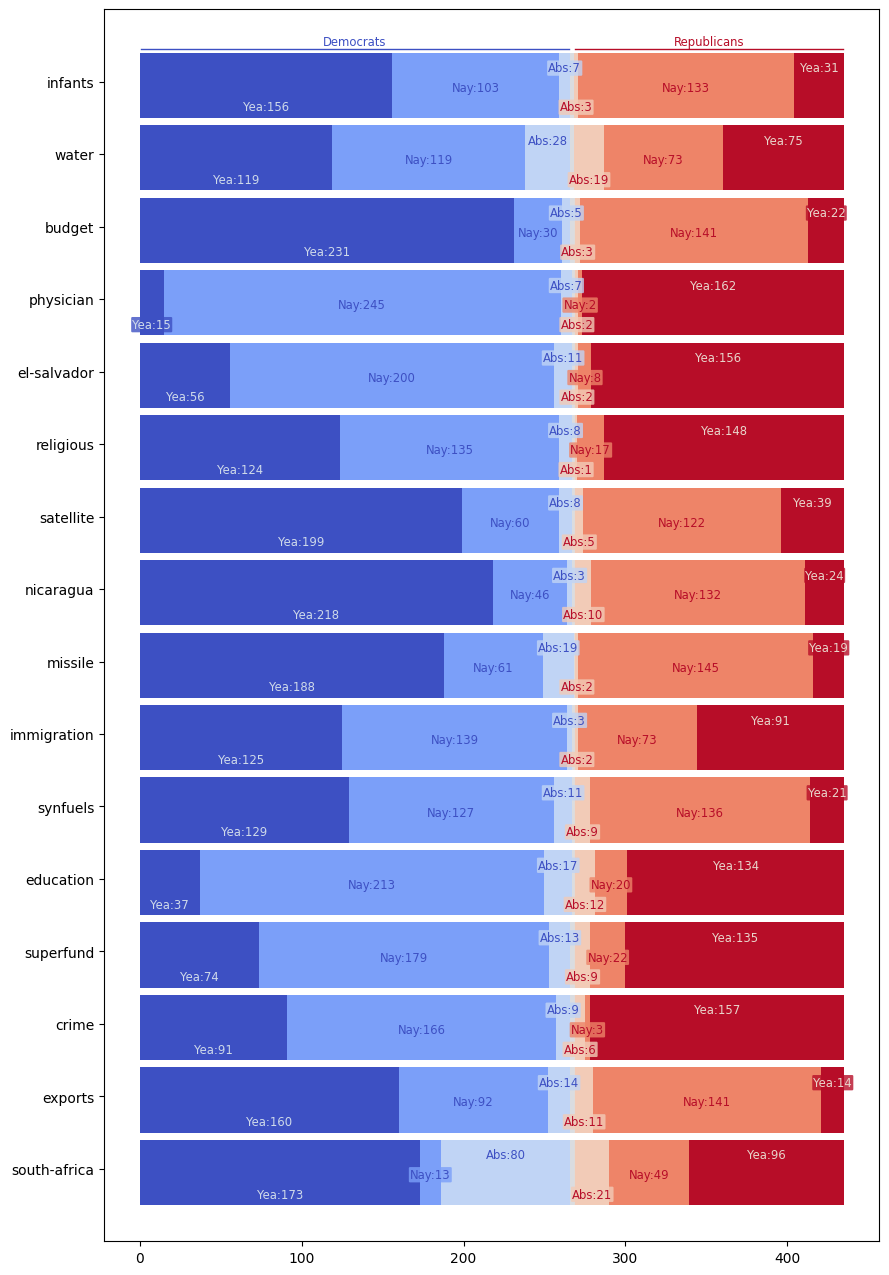

In [37]:
fig = plt.figure(figsize=(10, 16))
ax = fig.add_subplot()

plot_parameters = {"fontsize": "small"}
bar_params = []
for i, vote in enumerate(summary_rcs_dtf.index):
    series = pandas.Series([map_votes_vv.get(tuple(v)) for v in H84mv_dtf[["party_code", vote+suff_four]].values])

    bar_params.append(make_bar_stack(ax, series, codes_votes, plot_parameters, bottom=-i, height=0.9,
                                     yoffset_party_lbls=0.1 if i == 0 else None))

ax.set_yticks(*zip(*[(-i+.5, vote) for i, vote in enumerate(summary_rcs_dtf.index)]));
ax.set_ylim([-len(summary_rcs_dtf)+.5, 1.5]);

As expected, there are only few discrepancies when comparing to the [corresponding visualization of the distribution of vote types from the *UCI* dataset](#Visualizing-votes-per-party).

Note the narrow gray bar between the two parties, representing districts for which no vote was recorded, e.g. because the corresponding seat was vacant at the time of the vote.

## Mapping the data

Now that we have further information about the representatives, we know which congressional district each of them represents. Accordingly, for a given roll call, we can visualize the distribution of votes as a map.

For this purpose, we use the `geopandas` library (https://geopandas.org/en/stable), which builds on the `pandas` library, adding functionalities to handle geospatial data.

In [38]:
import geopandas

The United States Congressional District Shapefiles website at https://cdmaps.polisci.ucla.edu/ provides digital boundary definitions for every congressional district of the United States of America in use between 1789 and 2025.

We download the map data for the districts of the 98th Congress and load them.

In [39]:
H098districts_path = "./geo/districts098/districts098.shp"
H098districts_gdf = geopandas.read_file(H098districts_path, columns=["STATENAME", "DISTRICT"])\
    .rename({"STATENAME": "state", "DISTRICT": "district"}, axis=1)
H098districts_gdf

,state,district,geometry
0,Alabama,1.0,"MULTIPOLYGON (((-88.05205 30.19698, -88.05337 ..."
1,Alabama,2.0,"POLYGON ((-86.25816 32.50061, -86.25742 32.500..."
2,Alabama,3.0,"POLYGON ((-85.39404 33.93974, -85.39252 33.932..."
3,Alabama,4.0,"POLYGON ((-85.58322 34.8603, -85.58314 34.8603..."
4,Alabama,5.0,"POLYGON ((-85.59238 34.91049, -85.59232 34.909..."
...,...,...,...
432,Wisconsin,6.0,"MULTIPOLYGON (((-88.45524 44.18785, -88.45725 ..."
433,Wisconsin,7.0,"MULTIPOLYGON (((-90.70998 46.64066, -90.71324 ..."
434,Wisconsin,8.0,"MULTIPOLYGON (((-86.77505 45.36607, -86.77583 ..."
435,Wisconsin,9.0,"POLYGON ((-87.8791 43.09962, -87.87886 43.0989..."


We assign unique names to the records by combining state name and district number.

In [40]:
H098districts_gdf["name"] = ["%s-%03d" % tuple(v) for v in H098districts_gdf[["state", "district"]].values]
H098districts_gdf.set_index("name", inplace=True)

At-large districts are numbered with value 0, whereas in the *Voteview* data all districts are numbered starting from 1.
For a given state, if there is no district numbered 1, we use the district numbered 0 instead.

In [41]:
for v in H098districts_gdf.loc[H098districts_gdf["district"]==0, ["state", "district"]].values:
    one_k = "%s-%03d" % (v[0], 1)
    if one_k not in H098districts_gdf.index:
        print("Using at-large district as %s" % one_k)
        H098districts_gdf.loc[one_k] =  H098districts_gdf.loc["%s-%03d" % tuple(v)].copy()
        H098districts_gdf.loc[one_k,"name"] = one_k
        H098districts_gdf.loc[one_k,"district"] = 1
    else:
        print("Both at-large and %s exist" % one_k)

Using at-large district as Alaska-001
Using at-large district as Delaware-001
Using at-large district as District Of Columbia-001
Both at-large and Montana-001 exist
Using at-large district as North Dakota-001
Using at-large district as South Dakota-001
Using at-large district as Vermont-001
Using at-large district as Wyoming-001


We combine the geographic data with the *Voteview* table. The result is an extension of the `H84mv_dtf` table that contains geospatial information, so we denote it `H84mv_gdf`.

In [42]:
data_crs = "+proj=longlat +ellps=GRS80 +towgs84=0,0,0,0,0,0,0 +no_defs"
district_name = ["%s-%03d" % tuple(v) for v in H84mv_dtf[["state_long", "district_code"]].values]
H84mv_gdf = geopandas.GeoDataFrame(H84mv_dtf,
    geometry=H098districts_gdf.loc[district_name, "geometry"].values,
    crs=data_crs)
H84mv_gdf["name"] = ["%s-%03d" % tuple(v) for v in H84mv_dtf[["state_abbrev", "district_code"]].values]
H84mv_gdf.set_index("name", drop=False, inplace=True)

We also compute a rough estimate of the surface area of each district, as the sum of the areas of the polygons representing its geometry.

To do this, we need to project the geographic coordinates in a reference system that preserves area. That is, we need to use an [equal-area map projection](https://en.wikipedia.org/wiki/Equal-area_projection), such as the world sinusoidal projection, identified as `esri:54008`.

In [43]:
H84mv_gdf["surface_area"] = H84mv_gdf.to_crs("esri:54008").geometry.area*10**-6
H84mv_gdf[biofields+["surface_area"]]

,state_icpsr,district_code,state_abbrev,party_code,occupancy,last_means,bioname,born,died,surface_area
name,,,,,,,,,,
AL-001,41,1,AL,200,0,1,"EDWARDS, William Jackson (Jack)",1928.0,2019.0,21044.825099
AL-002,41,2,AL,200,0,1,"DICKINSON, William Louis",1925.0,2008.0,23982.680340
AL-003,41,3,AL,100,0,1,"NICHOLS, William Flynt",1918.0,1988.0,21490.003084
AL-004,41,4,AL,100,0,1,"BEVILL, Tom",1921.0,2005.0,24161.780051
AL-005,41,5,AL,100,0,1,"FLIPPO, Ronnie Gene",1937.0,NaN,13483.977325
...,...,...,...,...,...,...,...,...,...,...
WI-006,25,6,WI,200,0,1,"PETRI, Thomas Evert",1940.0,NaN,18160.878695
WI-007,25,7,WI,100,0,1,"OBEY, David Ross",1938.0,NaN,43891.778321
WI-008,25,8,WI,200,0,1,"ROTH, Toby A.",1938.0,NaN,26257.778663


We write a function for plotting geospatial data...

In [44]:
def make_plot(gdf, title, plot_parameters, crs, codes_votes=None, dtl_desc=None, save_path=None, ax=None, figsize=(16,10)):
    """Plots geospatial data.

        Parameters
        ----------
        gdf: GeoDataFrame
            The GeoDataFrame containing the feature values and the geometry of the objects to plot
        title: str
            The title of the plot
        plot_parameters: dict
            Parameters for plotting, especially "column" must be specified
            Optional parameters include
                "vmin", "vmax" and "palette", by default from 0 to 1 with "coolwarm" colormap
                "no_annot" ids of elements for which to skip annotation in the main map
                "insets" list of parameters for inset maps, including "ids" listing the elements to plot in the inset
        crs: pyproj.CRS
            The Coordinate Reference System (CRS) code of the projection to use for the map
        codes_votes: list of tuples
            The sorted list of (party, vote type) pairs with their associated numerical value, as used to obtain the column to plot,
            used to draw a histogram bar that also serves as legend, if None no histogram bar is drawn
        dtl_desc: str
            The detailed description of the roll call, added as text to the figure if not None
        save_path: str
            A filepath where to save the generated figure, works only if ax is None
        ax: pyplot.Axes
            The axes in which to plot the data, if None a new figure and subplot are created
        figsize: 2-tuple of floats
            Figure dimension (width, height) in inches
    """

    fig = None
    if ax is None:
        fig = plt.figure(1, figsize=figsize)
        ax = fig.add_subplot()

    legend_kwds = {}
    if codes_votes == True:
        legend_kwds = {"cax": ax.inset_axes(plot_parameters.get("bar_bounds", [0.55, 0.85, 0.45, 0.08])),
                        "orientation": "horizontal"}

    # Plotting main map
    drop_ids = set(plot_parameters.get("drop_ids", [])).union(*[ip["ids"] for ip in plot_parameters.get("insets", [])])
    main_pgdf = gdf.drop(drop_ids).to_crs(crs)

    main_plot_parameters = {"no_annot": drop_ids}
    main_plot_parameters.update(plot_parameters)
    main_pgdf.apply(lambda elem: annotate_element(ax, elem, main_plot_parameters), axis=1);
    main_pgdf.boundary.plot(ax=ax, color="Black", linewidth=.4, alpha=0.5);
    main_pgdf.plot(ax=ax, column=plot_parameters["column"],
                  vmin=plot_parameters.get("vmin", 0), vmax=plot_parameters.get("vmax", 1),
                  cmap=plot_parameters.get("cmap", "coolwarm"), legend=len(legend_kwds)>0, legend_kwds=legend_kwds)


    # Plotting inset maps
    for inset_parameters in plot_parameters.get("insets", []):
        inset_pgdf = gdf.loc[inset_parameters["ids"]].to_crs(inset_parameters.get("crs", crs))

        inset_ax = ax.inset_axes(inset_parameters.get("bounds", [0.01, 0.01, 0.1, 0.1]))

        inset_pgdf.apply(lambda elem: annotate_element(inset_ax, elem, plot_parameters), axis=1);
        inset_pgdf.boundary.plot(ax=inset_ax, color="Black", linewidth=.4, alpha=0.5);
        inset_pgdf.plot(ax=inset_ax, column=plot_parameters["column"],
                    vmin=plot_parameters.get("vmin", 0), vmax=plot_parameters.get("vmax", 1),
                    cmap=plot_parameters.get("cmap", "coolwarm"), legend=False)
        if "bbox_buffer" in inset_parameters:
            inset_ax.set_xlim([inset_parameters["bbox_buffer"][0],inset_parameters["bbox_buffer"][2]])
            inset_ax.set_ylim([inset_parameters["bbox_buffer"][1],inset_parameters["bbox_buffer"][3]])
        inset_ax.set_xticks([])
        inset_ax.set_yticks([])

    if codes_votes is not None and len(legend_kwds) == 0:
        bar_ax = ax.inset_axes(plot_parameters.get("bar_bounds", [0.55, 0.85, 0.45, 0.08]))
        make_bar_stack(bar_ax, gdf[plot_parameters["column"]], codes_votes, plot_parameters, set_lims=True)

    ylim = ax.get_ylim()
    if plot_parameters.get("bar_pad", 0) > 0:
        ax.set_ylim([ylim[0], ylim[1]+plot_parameters["bar_pad"]*(ylim[1]-ylim[0])])
    elif plot_parameters.get("bar_pad", 0) < 0:
        ax.set_ylim([ylim[0]+plot_parameters["bar_pad"]*(ylim[1]-ylim[0]), ylim[1]])
    if title is not None:
        ax.set_title(title)
    if dtl_desc is not None and fig is not None:
        fig.text(0.5, 0., dtl_desc, ha="center", wrap=True);

    ax.axis("off");

    if save_path is not None and fig is not None:
        fig.savefig(save_path)

    return ax

...and a function for annotating the elements of our plots.
A marker is drawn for districts with a surface area less than `max_area_marker`. A text label containing by default the name of the district is shown for districts with a surface area at least `min_area_label`.

In [45]:
def annotate_element(ax, elem, plot_parameters={}):
    """Prepare the annotation for an element.

        Parameters
        ----------
        ax: pyplot.Axes
            The axes in which to plot the data
        elem:
            The object to annotate
        plot_parameters : dict
            Parameters for plotting.
            Optional parameters include
                "vmin", "vmax" and "palette", by default from 0 to 1 with "coolwarm" colormap
                "no_annot" ids of elements for which to skip annotation
                "max_area_marker" maximum surface area of elements to annotate with a marker
                "min_area_label" minimum surface area of elements to annotate with a text label
                "label_str" a formatting string to prepare text labels, by default the element name is used
                "fontsize", "alpha", "mrk_alpha", "mrk_shape", "mrk_size", "mrk_edge"
"""

    if plot_parameters.get("no_annot") is None or elem.name not in plot_parameters.get("no_annot"):

        vfrac = (plot_parameters.get("vmax", 1) - elem[plot_parameters["column"]])/(
                    plot_parameters.get("vmax", 1) - plot_parameters.get("vmin", 0))
        palette = plot_parameters.get("palette", seaborn.color_palette("coolwarm", as_cmap=True))
        txt_color = get_contrasting_color(vfrac, palette)
        box_color = palette(1-vfrac)

        if elem["surface_area"] < plot_parameters.get("max_area_marker", -1):
            ax.plot(elem.geometry.centroid.coords[0][0], elem.geometry.centroid.coords[0][1],
                    color=box_color, markeredgecolor=txt_color,
                    marker=plot_parameters.get("mrk_shape", "o"), markersize=plot_parameters.get("mrk_size", 6),
                    markeredgewidth=plot_parameters.get("mrk_edge", 1), alpha=plot_parameters.get("mrk_alpha", 0.95), zorder=10)
        if elem["surface_area"] >= plot_parameters.get("min_area_label", -1):
            if "label_str" in plot_parameters:
                text = plot_parameters["label_str"].format(elem=elem)
            else:
                text = elem.name
            ax.annotate(text=text,
                xy=elem.geometry.centroid.coords[0],
                ha="center", fontsize=plot_parameters.get("fontsize", "x-small"), color=txt_color,
                bbox=dict(boxstyle="round", pad=.1, lw=0, fc=box_color, alpha=plot_parameters.get("alpha", 0.8)))

We choose a projection for the map and set parameters for the inset maps to represent Alaska and Hawaii.

In [46]:
# crs_main = 10598 # WGS_1984_GLANCE_North_America
# crs_main = 27705 # WGS_1984_Equi7_North_America
# crs_main = 3347 # NAD_1983_Statistics_Canada_Lambert
crs_main = "+proj=longlat +ellps=GRS80 +towgs84=0,0,0,0,0,0,0 +no_defs"

insets = [{"ids": ["AK-001"],
    "bounds": [0.01, 0.01, 0.25, 0.25],
    "bbox_buffer": [-180, 50, -127, 73],
    "crs": crs_main}, # "EPSG:4326"
    {"ids": ["HI-001", "HI-002"],
    "bounds": [0.18, 0.01, 0.2, 0.1],
    "bbox_buffer": [-161, 18, -154, 23],
    "crs": crs_main}
    ]

### Party affiliation

First, we simply plot the map with the districts colored based on the party affiliation of their representative.

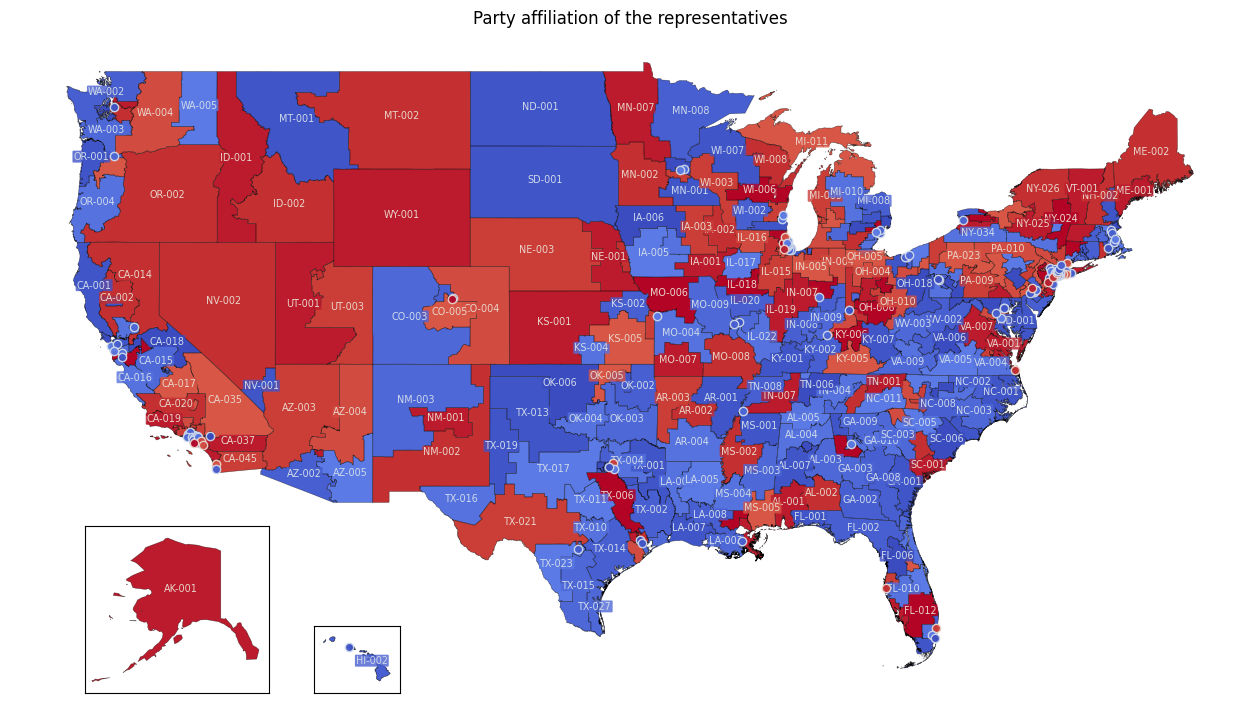

In [47]:
column = "state_district_num"
H84mv_gdf[column] = [(v[1]%6)/46 if v[0]==100 else 1-(v[1]%6)/46 for v in H84mv_gdf[["party_code", "district_code"]].values]

pp_sd = {"column": column,
    "max_area_marker": 10**3,
    "min_area_label": 10**4,
    "insets": insets,
    }

title_str = "Party affiliation of the representatives"
make_plot(H84mv_gdf, title_str, pp_sd, crs_main, None);

Districts with a representative from the Democratic Party are represented in shades of blue, whereas districts with a representative from the Republican Party are represented in shades of red.

The map allows us to see how the states were divided between the two parties in 1984 during the 98th Congress. States in the south-east had a majority of democrat representatives, while most of the vast inner western states had republican representatives, but no strong pattern is visible in party affiliation.

We can also focus on a subset of congressional districts. For instance, we apply a filter on state abbreviations, to keep only states of the Northeast US.

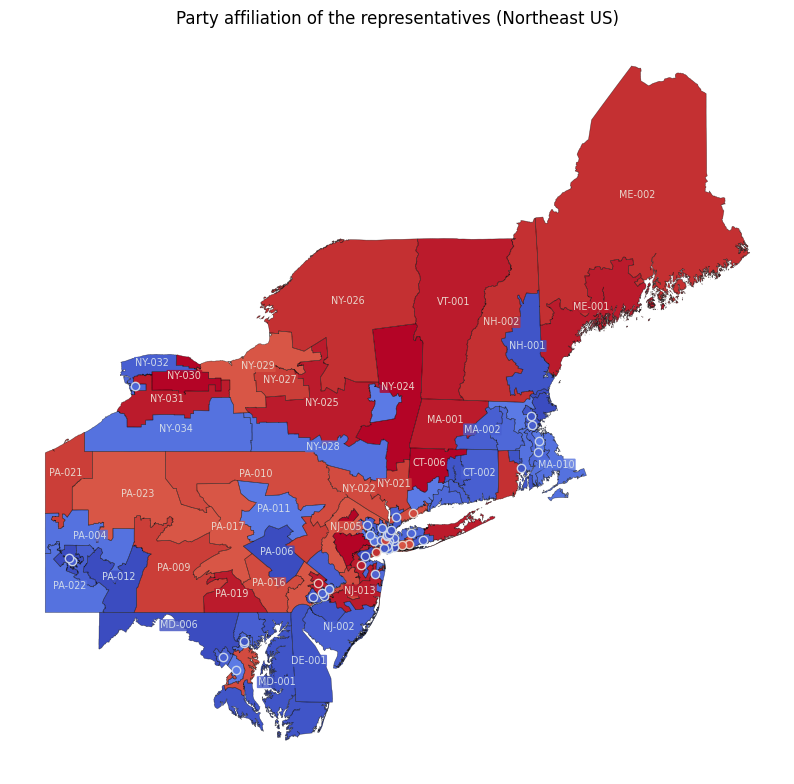

In [48]:
# Northeast US: Maine, New York, New Jersey, Vermont, Massachusetts,
#               Rhode Island, Connecticut, New Hampshire, Pennsylvania,
#               Delaware, Maryland, (District of Columbia)
states_NE = ["ME", "NY", "NJ", "VT", "MA", "RI", "CT", "NH", "PA", "DE", "MD", "DC"]
pp_NE = {"column": column,
    "max_area_marker": 10**3,
    "min_area_label": 2.5*10**3
    }

make_plot(H84mv_gdf.loc[H84mv_gdf["state_abbrev"].isin(states_NE)], title_str + " (Northeast US)", pp_NE, crs_main, None, figsize=(10,10));

### Roll call votes

We can also look at the distribution of votes across the congressional districts for a specific roll call.
As an example, we consider roll call #650 'satellite'.

https://voteview.com/rollcall/RH0980650
TO AMEND THE BROWN AMENDMENT TO H.R. 5167.  THE BROWN AMENDMENT PROHIBITS THE USE OF FUNDS AUTHORIZED IN THE BILL FOR THE TESTING OF THE SPACE DEFENSE SYSTEM (ANTISATELLITE WEAPON) AGAINST AN OBJECT IN SPACE UNLESS AND UNTIL THE PRESIDENT CERTIFIES TO CONGRESS THAT THE SOVIET UNION HAS CONDUCTED, AFTER THE DATE OF ENACTMENT OF THIS ACT, A TEST OF A DEDICATED ANTISATELLITE WEAPON. THE GORE AMENDMENT LIMITED TESTING UNTIL THE PRESIDENT CERTIFIED THAT NEITHER THE SOVIET UNION NOR ANY OTHER FOREIGN POWER HAD CONDUCTED A TEST OF A DEDICATED ANTI-SATELLITE WEAPON.  (MOTION PASSED)


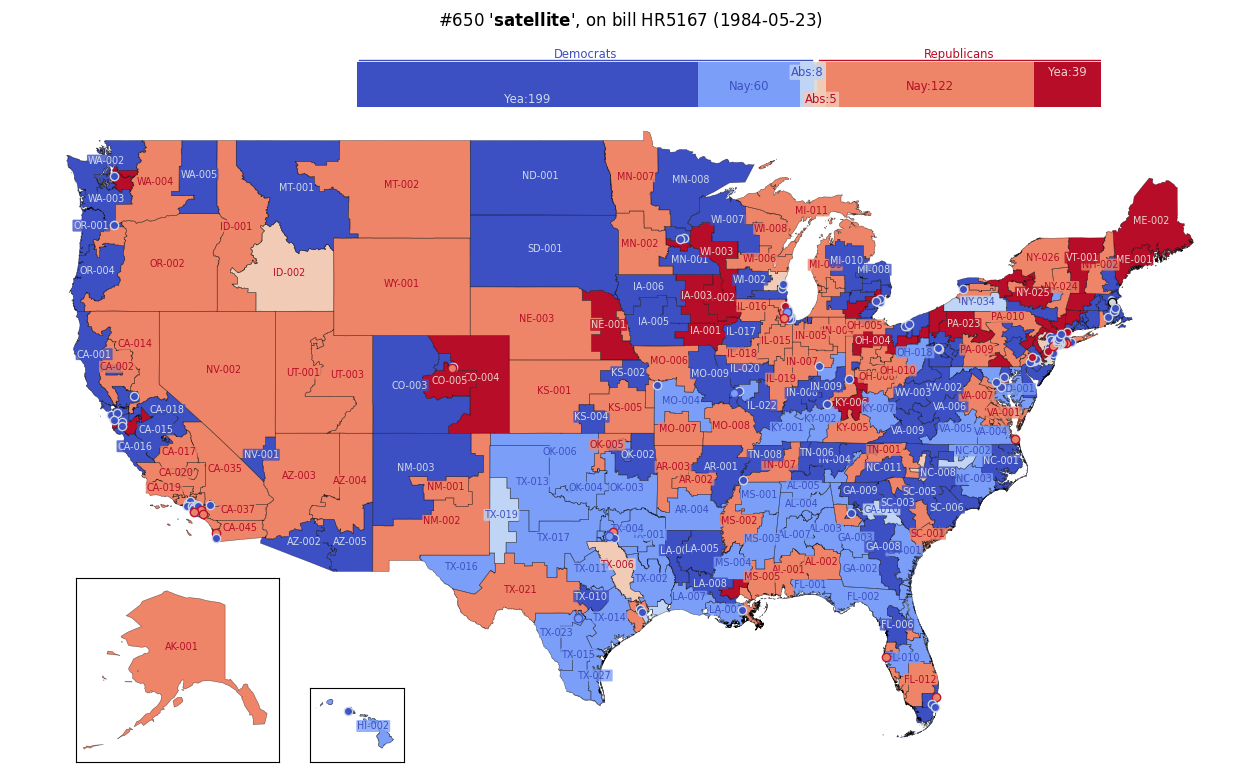

In [49]:
vote = "satellite"

column = "%s_party_num" % vote
title_patt = "#{rollnumber} '${{\\bf {vote}}}$', on bill {bill_number} ({date})"

H84mv_gdf[column] = [map_votes_vv.get(tuple(v)) for v in H84mv_gdf[["party_code", vote+suff_four]].values]

pp_rc = {"column": column,
    "max_area_marker": 10**3,
    "min_area_label": 10**4,
    "insets": insets,
    "bar_pad": 0.1,
    "bar_bounds": [0.28, 0.9, 0.6, 0.08]
    }

print(summary_rcs_dtf.at[vote, "vv_link"])
print(summary_rcs_dtf.at[vote, "dtl_desc"])
title_str = title_patt.format(vote=vote, **dict(summary_rcs_dtf.loc[vote].items()))
make_plot(H84mv_gdf, title_str, pp_rc, crs_main, codes_votes);

Again, districts with a representative from the Democratic Party are represented in shades of blue, whereas districts with a representative from the Republican Party are represented in shades of red.
Furthermore, bright shades represent 'Yea' votes, medium shades represent 'Nay' votes, light shades represent abstention.

For instance, we can see that the representatives of Colorado's third (CO-003), fourth (CO-004) and fifth (CO-005) districts all approved the bill, although the first is a democrat whereas the latter two are republicans.

Note that each district corresponds to one representative, i.e. one vote, irrespective of their surface area. At-large states like Alaska, Nevada, Wyoming or Montana, correspond to a single vote, as do the many districts in populous cities in California and on the Northeast coast which are represented by mere dots.
While the districts whose representative is a republican who voted 'Nay' cover a large part of the map, in fact they constitute less than a third of the votes.

Again, we can focus on states of the Northeast US.

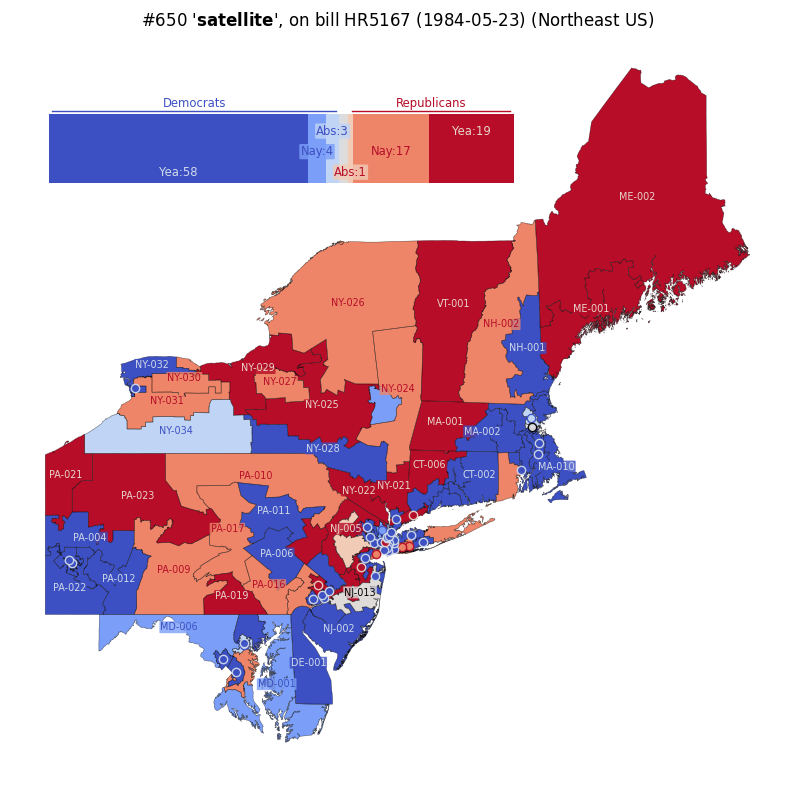

In [50]:
pp_NE["column"] = column
pp_NE["bar_bounds"] = [0.05, 0.8, 0.6, 0.12]

make_plot(H84mv_gdf.loc[H84mv_gdf["state_abbrev"].isin(states_NE)], title_str + " (Northeast US)", pp_NE, crs_main, codes_votes, figsize=(10,10));

In the Northeast US, we see that democrats voted overwhelmingly in favor of the bill whereas republicans are much more divided on this issue, with a narrow majority voting in favor of the bill. This is in contrast with republican votes in the rest of the country, since overall a clear majority of republicans opposed the bill.

We note that the thirteenth district of New Jersey (NJ-013) is depicted in gray, indicating that no vote was recorded for this district. Indeed the seat was vacant, following the [death of representative Edwin B. Forsythe in March 1984](https://en.wikipedia.org/wiki/Edwin_B._Forsythe).

We zoom in further, keeping only districts in the state of Massachusetts (MA) for the plot on the left-hand side and only districts of New York City, i.e. districts in the state of New York (NY) with district codes between 6 and 19, for the plot in the right-hand side.

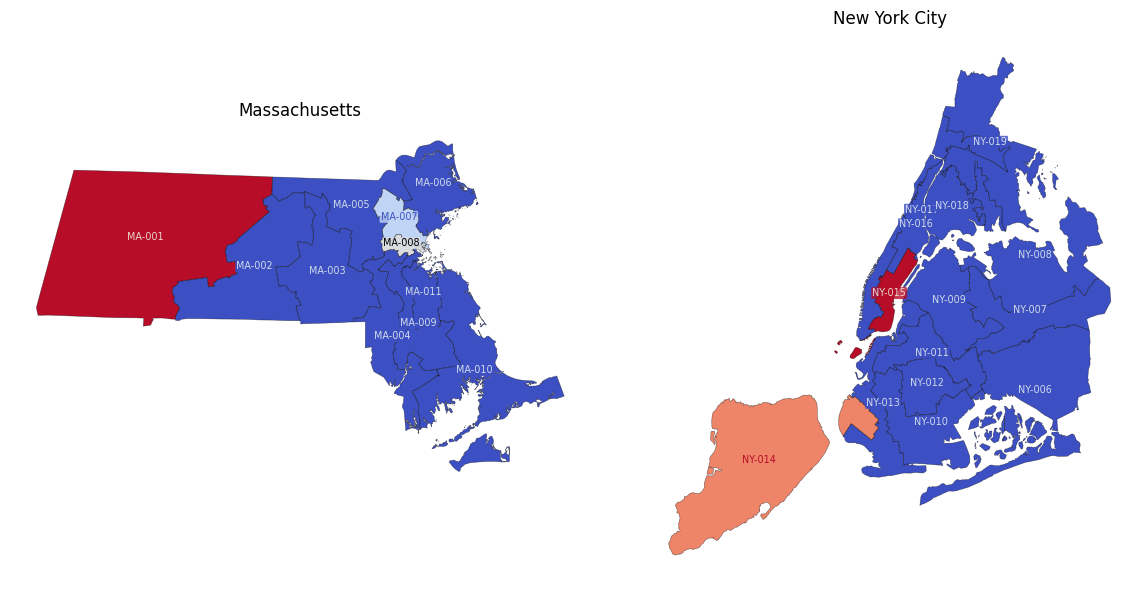

In [51]:
f, axes = plt.subplots(1, 2)
make_plot(H84mv_gdf.loc[H84mv_gdf["state_abbrev"] == "MA"], "Massachusetts", {"column": column}, crs_main, None, ax=axes[0]);
make_plot(H84mv_gdf.loc[(H84mv_gdf["state_abbrev"] == "NY") & (H84mv_gdf["district_code"].isin(range(6,20)))],
          "New York City", {"column": column}, crs_main, None, ax=axes[1]);

f.set_figheight(6)
f.set_figwidth(12)
f.tight_layout()

Only one of the representatives from New York City (NY-014), one of the two republicans, voted against the bill, all other representatives voted in favor.
Also just one of the representatives from Massachusetts opposed the bill. The eighth district of Massachusetts (MA-008) is depicted in gray, indicating that no vote was recorded for its representative, Thomas P. O'Neill, who was the speaker of the House at that time.

### Party alignment

Finally, we compute some statistics about how closely the representatives align with the majority vote within their own party.

That is, for each of the sixteen roll calls and for each party, we determine the mode, i.e. the most frequent value(s), among the votes of the representatives of that party.
We then create a new column `aligned_xxx`, where 'xxx' is the short name of the roll call, to record whether the representative's vote matches their party's majority vote.

The number of True values among these columns, stored in `aligned_count`, indicates on how many of the sixteen roll calls the representative's vote matches their party's majority vote.
We record on how many of the sixteen roll calls the representatives expressed a vote, i.e. where they voted either in favor or against, as `yn_count`.

We show an outline of the dataset sorted by these counts.

In [52]:
preff_align = "aligned_"
for vote in sel_short:
    for pc, party_name in party_codes.items():
        party_mode = H84mv_gdf.loc[H84mv_gdf["party_code"]==pc, vote+suff_four].mode().values
        if "?" in party_mode:
            print(f"The mode for {party_name}s on {vote} includes present and abstention votes.")
        H84mv_gdf.loc[H84mv_gdf["party_code"]==pc, preff_align+vote] = H84mv_gdf.loc[H84mv_gdf["party_code"]==pc, vote+suff_four].isin(party_mode)
H84mv_gdf[preff_align+"count"] = H84mv_gdf[[preff_align+vote for vote in sel_short]].astype(int).sum(axis=1)

H84mv_gdf["yn_count"] = H84mv_gdf[[vote+suff_four for vote in sel_short]].isin(["y", "n"]).astype(int).sum(axis=1)

H84mv_gdf.sort_values([preff_align+"count", "yn_count"])[[preff_align+"count", "yn_count"]+biofields]

,aligned_count,yn_count,state_icpsr,district_code,state_abbrev,party_code,occupancy,last_means,bioname,born,died
name,,,,,,,,,,,
NJ-013,0,0,12,13,NJ,200,0,1,"FORSYTHE, Edwin Bell",1916.0,1984.0
FL-010,0,15,43,10,FL,100,0,1,"IRELAND, Andrew Poysell (Andy)",1930.0,2024.0
MA-008,1,1,3,8,MA,100,0,1,"O'NEILL, Thomas Philip (Tip), Jr.",1912.0,1994.0
ID-002,2,2,63,2,ID,200,0,1,"HANSEN, George Vernon",1930.0,2014.0
TX-017,3,15,49,17,TX,100,0,1,"STENHOLM, Charles Walter",1938.0,2023.0
...,...,...,...,...,...,...,...,...,...,...,...
CA-041,16,16,71,41,CA,200,0,1,"LOWERY, William David",1947.0,NaN
CA-042,16,16,71,42,CA,200,0,1,"LUNGREN, Daniel Edward",1946.0,NaN
IL-009,16,16,21,9,IL,100,0,1,"YATES, Sidney Richard",1909.0,2000.0


We see that Andy Ireland is among the representatives with the lowest alignment. Indeed none of his fifteen expressed votes aligned with the majority vote of the Democratic Party, under which he was elected and to which he is affiliated according to this data. We recall that he switched to the Republican Party during the 1984 congressional session.

We make heatmaps to show the distribution of the number of expressed votes vs. number of votes aligned with the party majority, separately for the Democratic Party, on the left-hand side, and for the Republican party, on the right-hand side. The number in each cell indicates how many representatives from the considered party had the number of expressed votes and of votes aligned with the party majority of the corresponding column and row, respectively.
The plotted values are scaled so that the color intensity varies proportionally to the corresponding fraction of party members, to make the two plots comparable.

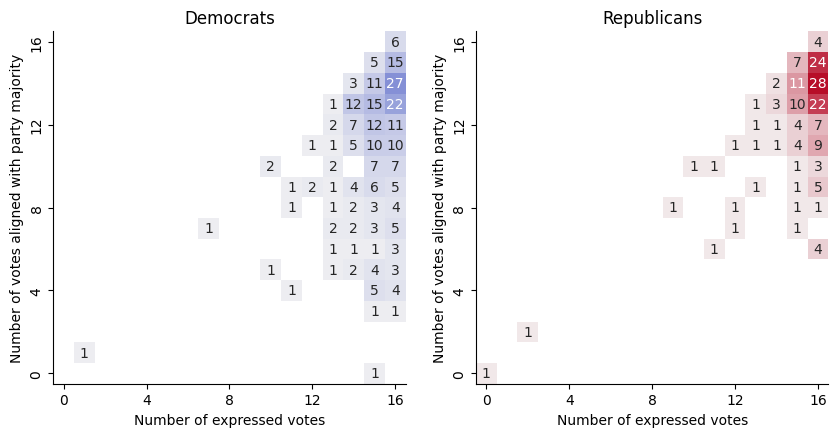

In [53]:
all_counts = {}
yn_max = H84mv_gdf["yn_count"].max()
im_max = H84mv_gdf[preff_align+"count"].max()
vmax = 0

for i, (pc, pname) in enumerate(party_codes.items()):
    all_counts[pname] = numpy.zeros((im_max+1, yn_max+1))
    cc = H84mv_gdf.loc[H84mv_gdf["party_code"]==pc, ["yn_count", preff_align+"count"]].value_counts().reset_index()\
        .pivot(index="yn_count", columns=preff_align+"count", values="count").fillna(0)
    all_counts[pname][*numpy.meshgrid(cc.columns.values, cc.index.values)] = cc.to_numpy()
    vmax = numpy.maximum(vmax, all_counts[pname].max()/all_counts[pname].sum())

base_colors = seaborn.color_palette("coolwarm", as_cmap=True)([0.01, 0.99])
f, axes = plt.subplots(1, 2)
for i, (pc, pname) in enumerate(party_codes.items()):
    vs = all_counts[pname]/all_counts[pname].sum()
    vs[vs==0] = numpy.nan
    seaborn.heatmap(vs, cmap=seaborn.light_palette(base_colors[i], as_cmap=True), vmin=0, vmax=vmax,
                    annot=all_counts[pname], cbar=False, xticklabels=4, yticklabels=4, square=True, ax=axes[i])
    axes[i].invert_yaxis()
    axes[i].spines["bottom"].set_visible(True)
    axes[i].spines["left"].set_visible(True)
    axes[i].set_xlabel("Number of expressed votes")
    axes[i].set_ylabel("Number of votes aligned with party majority")
    axes[i].set_title(pname.capitalize()+"s")

The proportion of representatives with high numbers of expressed and aligned votes is higher among republicans than among democrats, as visible from brighter shades in the top right corner of the right-hand side plot than in the left-hand side plot.
Republican votes seem to be overall more aligned.

In addition, we see that most representatives abstained at least once.

We visualize the number of votes aligned with party majority on a map.

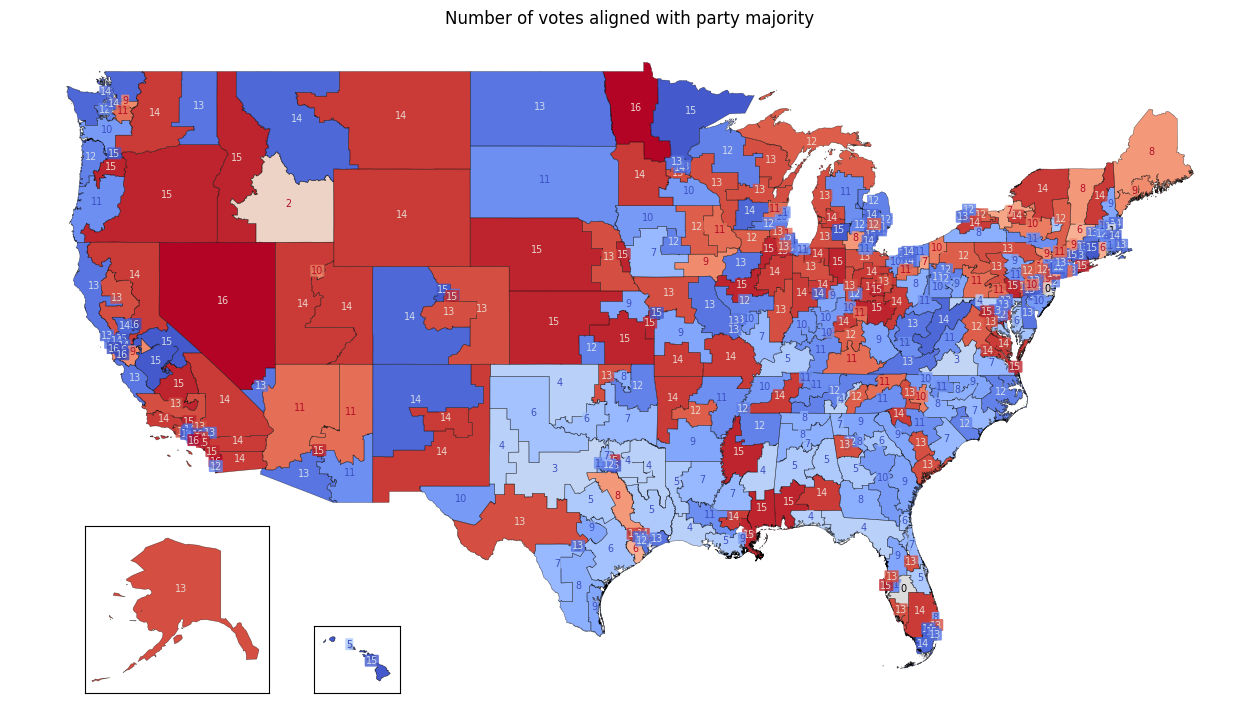

In [54]:
column = preff_align+"ratio_num"
H84mv_gdf[column] = [(1-v[0]/16)/2 if v[1]==100 else 1-(1-v[0]/16)/2 for v in H84mv_gdf[[preff_align+"count", "party_code"]].values]

pp_sd = {"column": column,
    "insets": insets,
    "label_str": "{elem."+preff_align+"count}"
    }

title_str = "Number of votes aligned with party majority"
make_plot(H84mv_gdf, title_str, pp_sd, crs_main, None);

Bright shades of the representative's party color indicate that a higher number of the representative's votes match the party majority, whereas districts whose representative's votes often diverge from the party majority are depicted with light shades of that party's color.

Democrats from south-eastern states have some of the lowest numbers of aligned votes, with as little as three or four votes of representatives from some districts in Texas, Oklahoma and Florida, for instance, matching the party majority.

On the other hand, many republican representatives almost perfectly align with the party majority, with republicans representative from districts in Montana, Wyoming, Nevada, or Kansas, for example, having fourteen or more aligned votes.